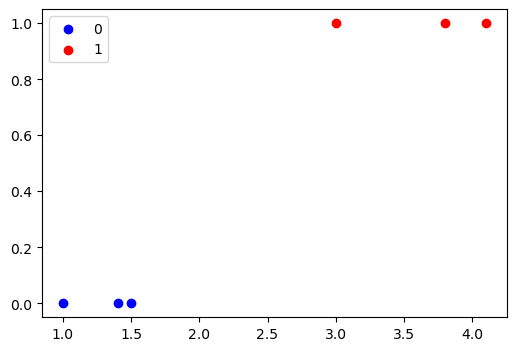

In [60]:
import numpy as np
import matplotlib.pyplot as plt
import random

data = np.genfromtxt('iris_1D.csv', dtype = float, delimiter=',', skip_header=1) #Đọc file, kiểu dữ liệu float, được cách nhau bởi dấu phẩy, bỏ header 
X = data[:,:1]  #Lấy tất cả giá trị, cột 0, tạo thành mảng 2 chiều
y = data[:,1] #Lấy tất cả giá trị, cột 1, tạo thành mảng 1 chiều
N = X.shape[0] #Số lần học qua mỗi điểm trong data


plt.figure(figsize = (6,4))
plt.scatter(X[y==0][:, 0] ,y[y==0], color = 'b', label ='0')  #Vẽ đồ thị chấm, lấy giá trị x có y =0, và y =0
plt.scatter(X[y==1][:, 0] ,y[y==1], color = 'r', label ='1') #Vẽ đồ thị chấm, lấy giá trị x có y =1, và y =1
plt.legend()
plt.show
matrix_ones = np.ones([X.shape[0],X.shape[1]]) # tạo intercept 
X = np.concatenate((matrix_ones,X), axis = 1) # nối intercept với X lại theo chiều x 

In [61]:
def sigmoid_function(z):
    return 1 / (1 + np.exp(-z))

def loss_function(y_hat, y):
    return -y * np.log(y_hat) - (1 - y) * np.log(1 - y_hat)

def predict(X, theta):    
    y_hat = sigmoid_function(np.dot(X, theta))
    return y_hat

def compute_gradient(x, y_hat, y):
    return x*(y_hat - y)

lr = 0.01
num_iter = 5000 # số lần học lại qua dữ liệu

#Khởi tạo theta ngẫu nhiên 
theta =[random.random()-random.random(), random.random()-random.random()]

losses = []
accs = []

for _ in range(num_iter):
    #for each sample
    for i in range(N):
        xi = X[i]
        yi= y[i]

        #predict z
        y_hat = predict(xi, theta)

        #compute loss
        loss = loss_function(y_hat, yi)
        gradient = compute_gradient(xi, y_hat, yi)

        #compute gradient
        theta -= lr*gradient

        #debug
        losses.append(loss)

    #Xem accuracy cho training 
    preds = predict(X, theta).round() #Tính những số dưới 0.5 = 0 và trên 0.5 = 1
    acc = (preds == y).mean() #So sanh dự đoán và chia trung bình để tính độ chính xác
    accs.append(acc)






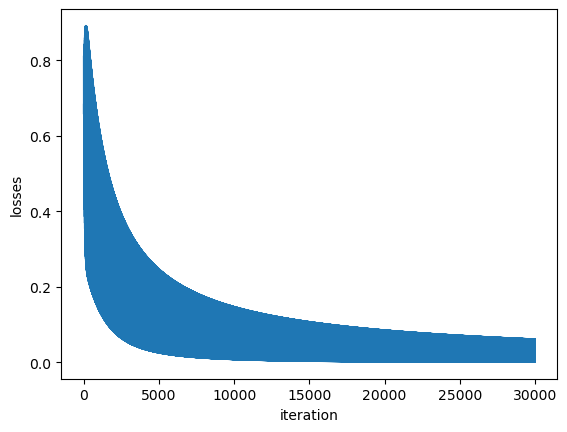

In [62]:
import matplotlib.pyplot as plt

plt.plot(losses[1:])
plt.xlabel('iteration')
plt.ylabel('losses')
plt.show()

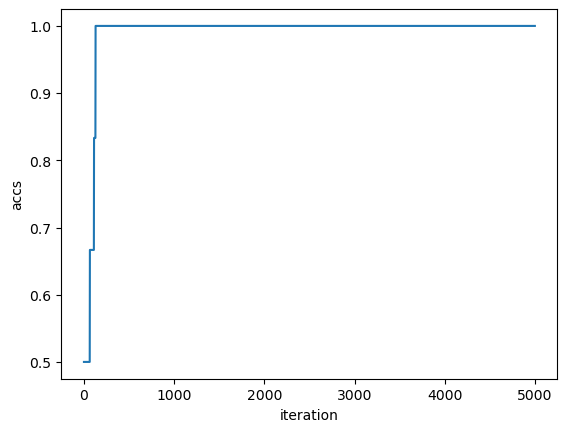

In [63]:
import matplotlib.pyplot as plt

plt.plot(accs[1:])
plt.xlabel('iteration')
plt.ylabel('accs')
plt.show()